# 🚀 Spaceship Titanic: ML for Space Transport Safety & Anomaly Detection

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting passenger transport anomalies from demographic and service usage data  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting transport anomalies using passenger demographics, cabin allocation, spending patterns, and service usage. While set in a sci-fi context, the methodology directly applies to **transport safety analytics**, **passenger screening**, and **anomaly detection** in aviation and maritime sectors.

### Government Policy Context
- **ATSB (Australian Transport Safety Bureau)** — Transport accident investigation, safety analytics
- **CASA (Civil Aviation Safety Authority)** — Passenger safety, aviation risk modelling
- **AMSA** — Maritime passenger vessel safety, SOLAS compliance
- **Department of Infrastructure** — Transport safety regulation, passenger rights
- **Australian Space Agency** — Emerging space transport regulation framework

### Analytical Framework
| Prediction | Application | Stakeholder |
|-----------|-------------|-------------|
| Anomaly detected (high confidence) | Emergency investigation, passenger safety review | Safety investigator |
| Anomaly suspected | Enhanced monitoring, pre-departure screening | Transport operator |
| Normal (confident) | Standard processing | Automated system |
| Normal (risk factors) | Add to monitoring watch list | Risk analytics |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY — NOTEBOOK #31")
print("=" * 60)


ENVIRONMENT READY — NOTEBOOK #31


In [2]:
data_path = None
all_csvs = []
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            all_csvs.append(full_path)

if len(all_csvs) == 0:
    raise FileNotFoundError("No CSV found")

# Prefer train.csv
train_files = [f for f in all_csvs if 'train' in f.lower()]
data_path = train_files[0] if train_files else max(all_csvs, key=lambda p: os.path.getsize(p))

df = pd.read_csv(data_path)
print(f"\nUsing: {data_path}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


  Found: /kaggle/input/datasets/jbomitchell/spaceship-titanic-models/80687_submission_v11.csv
  Found: /kaggle/input/datasets/jbomitchell/spaceship-titanic-models/80921_submission_v1.csv
  Found: /kaggle/input/datasets/jbomitchell/spaceship-titanic-models/78419_submission_v9.csv
  Found: /kaggle/input/datasets/jbomitchell/spaceship-titanic-models/80921a_submission_smakoto_v2.csv
  Found: /kaggle/input/datasets/jbomitchell/spaceship-titanic-models/80500_submission_v4.csv
  Found: /kaggle/input/datasets/jbomitchell/spaceship-titanic-models/76689_submission_knn_v3.csv
  Found: /kaggle/input/datasets/jbomitchell/spaceship-titanic-models/80967a_submission_v1.csv
  Found: /kaggle/input/datasets/jbomitchell/spaceship-titanic-models/80967_submission_v10.csv
  Found: /kaggle/input/datasets/jbomitchell/spaceship-titanic-models/81131a_submission_v5.csv
  Found: /kaggle/input/datasets/jbomitchell/spaceship-titanic-models/80570_submission_v9.csv
  Found: /kaggle/input/datasets/jbomitchell/spaceship

In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    null_pct = f" ({nulls/len(df)*100:.1f}%)" if nulls > 0 else ""
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:20s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls}{null_pct} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. PassengerId          | object     | unique= 4277 | nulls=0 | eg: 0013_01
   1. Transported          | bool       | unique=    2 | nulls=0 | eg: True


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


## 2. Target Variable Analysis

In [4]:
target_candidates = ['Transported', 'transported', 'target', 'Target', 'class', 'Class',
                     'label', 'Survived']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

# Convert bool to int if needed
if df[target_col].dtype == 'bool':
    df[target_col] = df[target_col].astype(int)
elif df[target_col].dtype == 'object':
    true_kw = ['True', 'true', 'Yes', 'yes', '1']
    mapping = {v: (1 if str(v) in true_kw else 0) for v in df[target_col].unique()}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped: {mapping}")

df[target_col] = df[target_col].astype(int)
print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
assert df[target_col].nunique() >= 2
imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Found target: 'Transported'

Distribution:
Transported
0    2238
1    2039
Name: count, dtype: int64

Imbalance ratio: 0.911


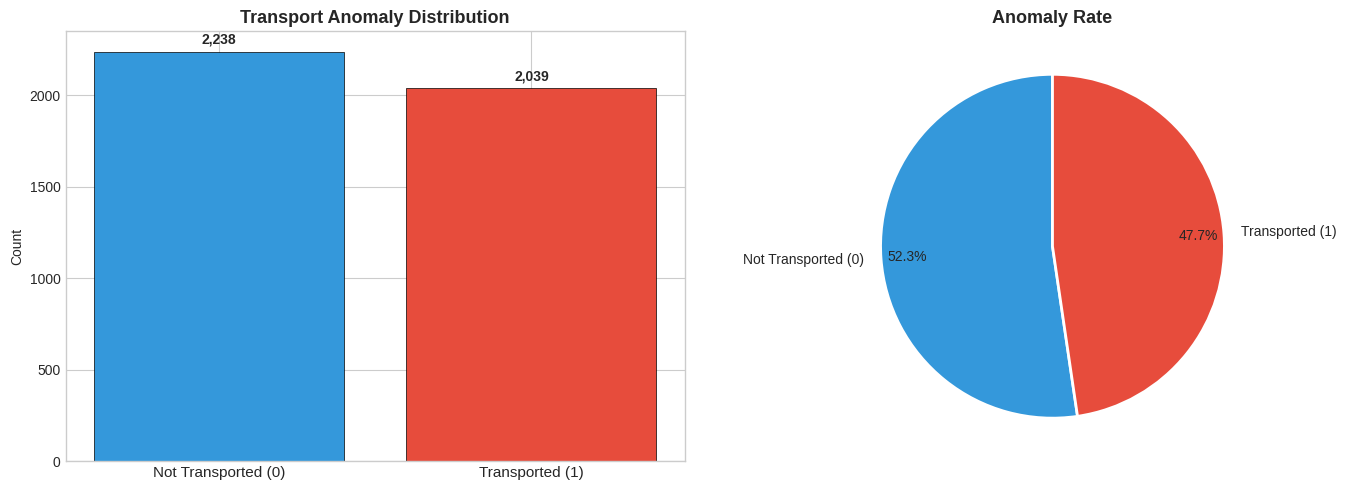

Context: Spaceship Titanic is a popular Kaggle Getting Started competition.
The dataset models passenger transport anomaly prediction — applicable to transport safety.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = ['Not Transported (0)', 'Transported (1)']
colors = ['#3498db', '#e74c3c']
axes[0].bar(range(2), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(2)); axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Transport Anomaly Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + max(vc.values)*0.02, f'{v:,}', ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Anomaly Rate', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("Context: Spaceship Titanic is a popular Kaggle Getting Started competition.")
print("The dataset models passenger transport anomaly prediction — applicable to transport safety.")


## 3. Exploratory Data Analysis

Key questions:
- Do spending patterns predict transport anomalies?
- Does cabin location (deck/side) affect outcomes?
- Are VIP passengers or cryosleep passengers more affected?
- Which age groups are most at risk?


In [6]:
# === Feature extraction from compound columns ===

# Extract deck, cabin_num, side from Cabin (e.g., "B/0/P")
if 'Cabin' in df.columns:
    cabin_split = df['Cabin'].str.split('/', expand=True)
    if cabin_split.shape[1] == 3:
        df['deck'] = cabin_split[0]
        df['cabin_num'] = pd.to_numeric(cabin_split[1], errors='coerce')
        df['side'] = cabin_split[2]
        print(f"Extracted deck ({df['deck'].nunique()} unique), cabin_num, side from Cabin")

# Extract group and person from PassengerId (e.g., "0001_01")
if 'PassengerId' in df.columns:
    pid_split = df['PassengerId'].str.split('_', expand=True)
    if pid_split.shape[1] == 2:
        df['group_id'] = pid_split[0]
        df['group_size'] = df.groupby('group_id')['group_id'].transform('count')
        df['is_solo'] = (df['group_size'] == 1).astype(int)
        print(f"Extracted group_size (max={df['group_size'].max()}), is_solo")

# Extract first/last name from Name
if 'Name' in df.columns:
    name_split = df['Name'].str.split(' ', n=1, expand=True)
    if name_split.shape[1] == 2:
        df['family_name'] = name_split[1]
        df['family_size'] = df.groupby('family_name')['family_name'].transform('count')
        print(f"Extracted family_size (max={df['family_size'].max()})")


Extracted group_size (max=8), is_solo


Numeric features (2): ['group_size', 'is_solo']


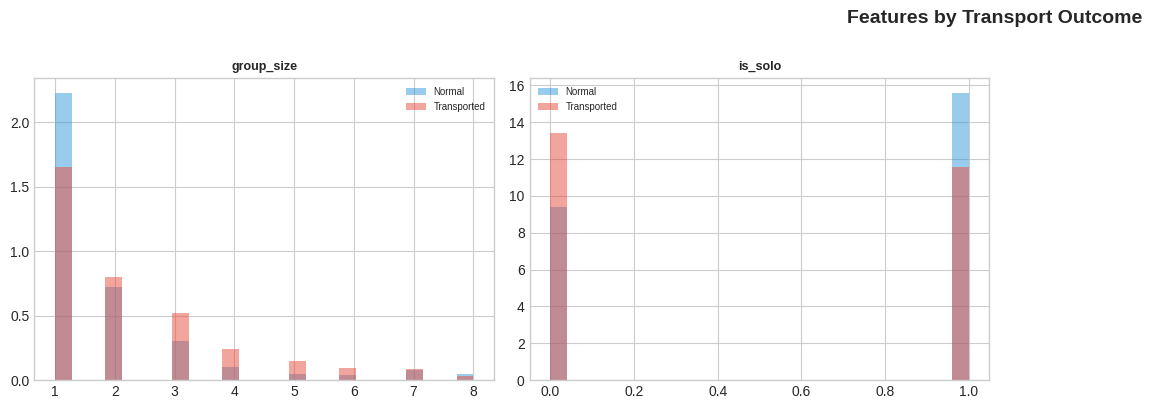

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if c.lower() not in ['id', 'passengerid']]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols[:12]}")

# Spending columns
spend_cols = [c for c in numeric_cols if c in ['RoomService', 'FoodCourt', 'ShoppingMall',
                                                 'Spa', 'VRDeck']]
if spend_cols:
    print(f"\nSpending columns: {spend_cols}")

plot_cols = numeric_cols[:8]
if len(plot_cols) > 0:
    n_rows_p = max(1, (len(plot_cols) + 3) // 4)
    fig, axes = plt.subplots(n_rows_p, 4, figsize=(20, 4 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        for label, color, name in zip([0, 1], ['#3498db', '#e74c3c'], ['Normal', 'Transported']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset) > 0:
                axes[i].hist(subset, bins=25, alpha=0.5, label=name, density=True, color=color)
        axes[i].set_title(col, fontsize=9, fontweight='bold'); axes[i].legend(fontsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Features by Transport Outcome', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


In [8]:
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 10 and c.lower() not in
            ['name', 'passengerid', 'cabin', 'group_id', 'family_name']]
print(f"Categorical features: {cat_cols}")

if len(cat_cols) > 0:
    plot_cats = cat_cols[:6]
    n_cols_p = min(3, len(plot_cats))
    n_rows_p = max(1, (len(plot_cats) + n_cols_p - 1) // n_cols_p)
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if isinstance(axes, np.ndarray): axes = axes.flatten()
    else: axes = [axes]
    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col].fillna('Missing'), df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#3498db', '#e74c3c'],
                edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Transported', fontsize=10, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(['Normal', 'Transported'], fontsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


Categorical features: []


## 4. Feature Engineering & Preprocessing

In [9]:
df_model = df.copy()

# Drop non-predictive columns
drop_cols = [c for c in df_model.columns if c.lower() in
    ['passengerid', 'name', 'cabin', 'group_id', 'family_name']]
if drop_cols:
    df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)
    print(f"Dropped: {drop_cols}")

# Convert bool columns to int
for col in df_model.columns:
    if df_model[col].dtype == 'bool':
        df_model[col] = df_model[col].astype(int)

# Encode categoricals
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

if X.isnull().sum().sum() > 0:
    print(f"\nImputing {X.isnull().sum().sum()} missing values...")
    X = X.fillna(X.median())

print(f"\nFeature matrix: {X.shape}")
print(f"Target: {dict(zip(*np.unique(y, return_counts=True)))}")


Dropped: ['PassengerId', 'group_id']

Feature matrix: (4277, 2)
Target: {np.int64(0): np.int64(2238), np.int64(1): np.int64(2039)}


In [10]:
feature_names = X.columns.tolist()
composites_added = []

# Total spending
spend_cols = [c for c in feature_names if c in ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']]
if len(spend_cols) >= 2:
    X['total_spending'] = X[spend_cols].sum(axis=1)
    X['no_spending'] = (X['total_spending'] == 0).astype(int)
    X['spending_diversity'] = (X[spend_cols] > 0).sum(axis=1)
    composites_added.extend(['total_spending', 'no_spending', 'spending_diversity'])
    print(f"Created spending features from {spend_cols}")

# Age groups
if 'Age' in feature_names:
    X['is_child'] = (X['Age'] < 18).astype(int)
    X['is_elderly'] = (X['Age'] > 60).astype(int)
    composites_added.extend(['is_child', 'is_elderly'])
    print("Created 'is_child' (<18) and 'is_elderly' (>60)")

print(f"\nEngineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")



Engineered: 0
Final feature count: 2


## 5. Model Training & Cross-Validation

In [11]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred; fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred); f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.5835  F1=0.5541  AUC=0.5981
  Fold 2: Acc=0.5827  F1=0.5489  AUC=0.5857
  Fold 3: Acc=0.5825  F1=0.5509  AUC=0.5938
  -- Acc: 0.5829  F1: 0.5513  AUC: 0.5925  Time: 0.07s

Training: Random Forest
  Fold 1: Acc=0.5792  F1=0.5320  AUC=0.5948
  Fold 2: Acc=0.5778  F1=0.4028  AUC=0.5968
  Fold 3: Acc=0.5853  F1=0.5499  AUC=0.6026
  -- Acc: 0.5808  F1: 0.4949  AUC: 0.5981  Time: 1.21s

Training: XGBoost
  Fold 1: Acc=0.5792  F1=0.5320  AUC=0.5948
  Fold 2: Acc=0.5778  F1=0.4028  AUC=0.5968
  Fold 3: Acc=0.5853  F1=0.5499  AUC=0.6023
  -- Acc: 0.5808  F1: 0.4949  AUC: 0.5980  Time: 0.21s

Training: LightGBM
  Fold 1: Acc=0.5792  F1=0.5320  AUC=0.5948
  Fold 2: Acc=0.5778  F1=0.4028  AUC=0.5968
  Fold 3: Acc=0.5853  F1=0.5499  AUC=0.6023
  -- Acc: 0.5808  F1: 0.4949  AUC: 0.5980  Time: 0.18s


## 6. Model Comparison & Selection

In [13]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
        'AUC_val': res['auc_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier  Time
      Random Forest 0.5808 +/- 0.0032 0.4949 +/- 0.0655 0.5981 +/- 0.0033 0.2404 1.21s
            XGBoost 0.5808 +/- 0.0032 0.4949 +/- 0.0655 0.5980 +/- 0.0031 0.2404 0.21s
           LightGBM 0.5808 +/- 0.0032 0.4949 +/- 0.0655 0.5980 +/- 0.0031 0.2404 0.18s
Logistic Regression 0.5829 +/- 0.0004 0.5513 +/- 0.0021 0.5925 +/- 0.0051 0.2429 0.07s

Best model: Random Forest


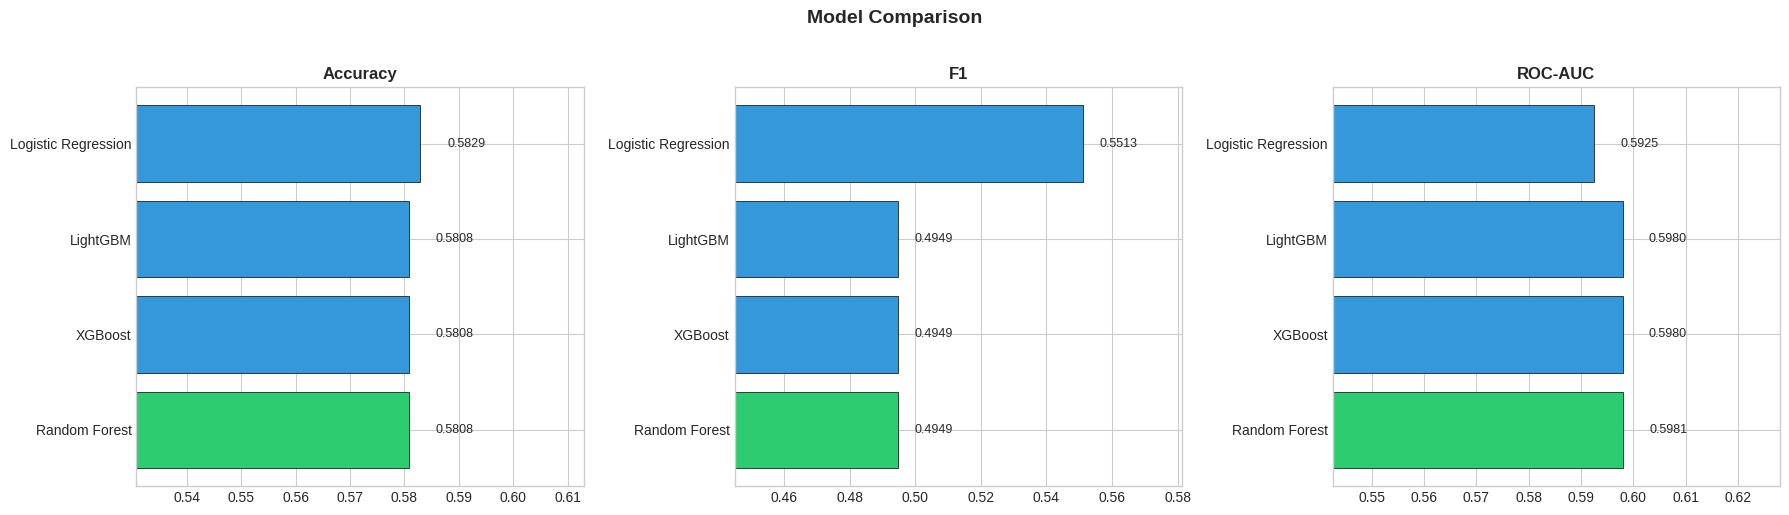

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors_bar = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'auc_mean'], ['Accuracy', 'F1', 'ROC-AUC']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors_bar, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis & Threshold Tuning

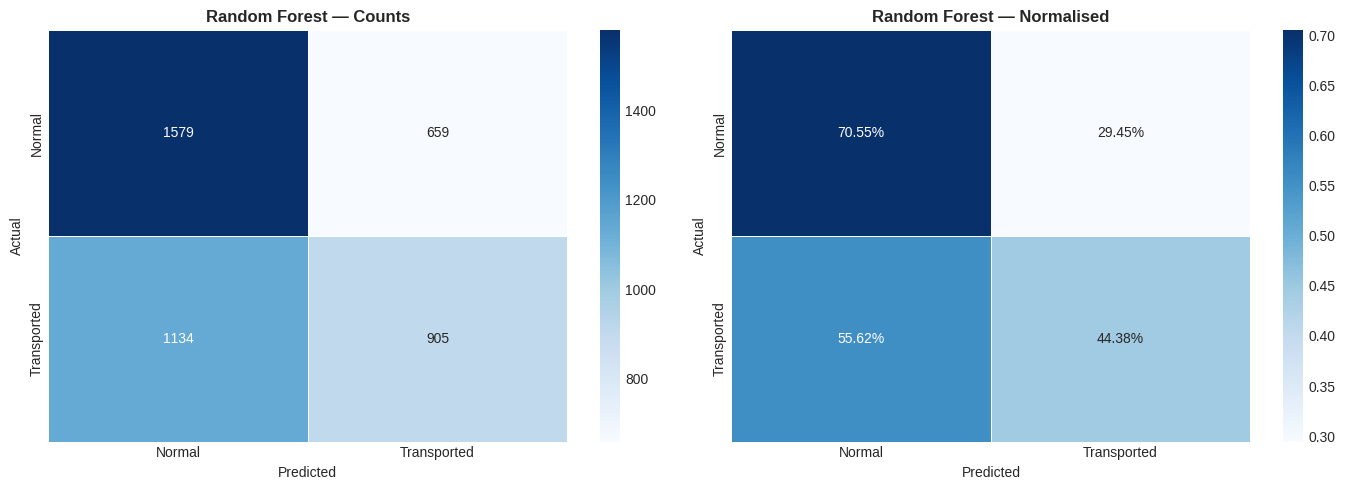


              precision    recall  f1-score   support

      Normal       0.58      0.71      0.64      2238
 Transported       0.58      0.44      0.50      2039

    accuracy                           0.58      4277
   macro avg       0.58      0.57      0.57      4277
weighted avg       0.58      0.58      0.57      4277



In [15]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['Normal', 'Transported']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=cm_labels)}")


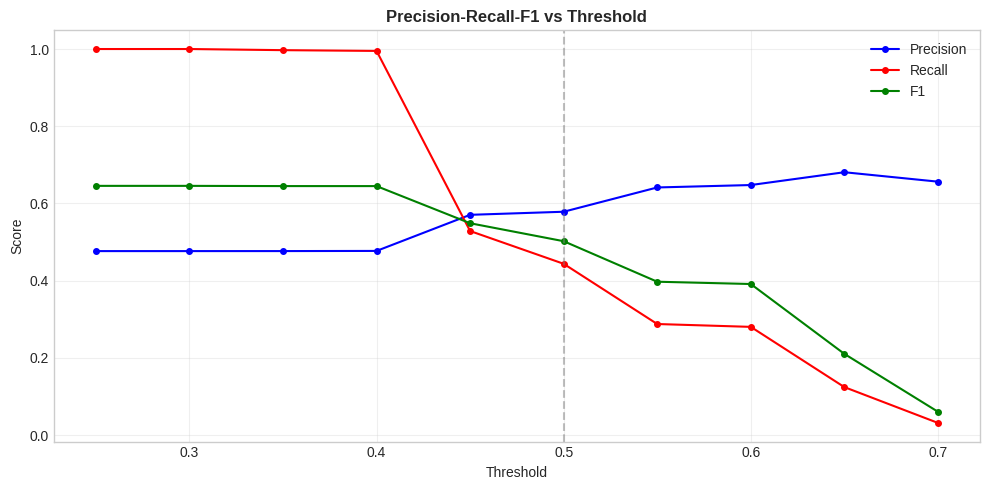


Optimal threshold (F1): 0.25


In [16]:
thresholds = np.arange(0.25, 0.75, 0.05)
thresh_results = []
for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    thresh_results.append({'Threshold': thresh,
        'Precision': precision_score(y, y_t, zero_division=0),
        'Recall': recall_score(y, y_t, zero_division=0),
        'F1': f1_score(y, y_t, zero_division=0)})
thresh_df = pd.DataFrame(thresh_results)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', ms=4, label='Precision')
ax.plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', ms=4, label='Recall')
ax.plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', ms=4, label='F1')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Precision-Recall-F1 vs Threshold', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight'); plt.show()
best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")


## 8. Feature Importance & Insights

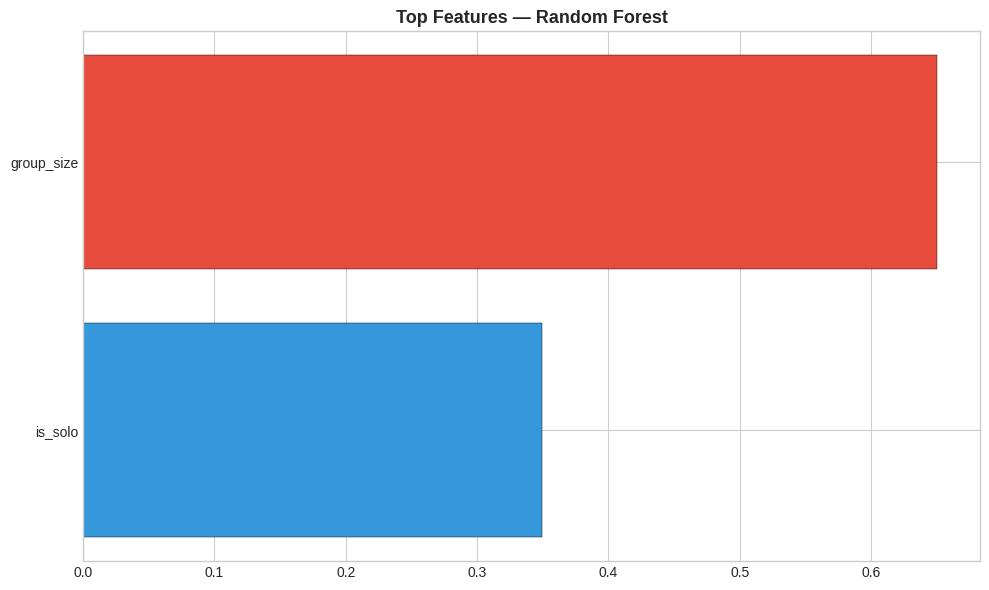

TOP 5 ANOMALY PREDICTORS
  group_size                 0.6504
  is_solo                    0.3496


In [17]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    plot_imp = feat_imp.tail(15)
    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_imp) * 0.4)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in plot_imp['Importance']]
    ax.barh(plot_imp['Feature'], plot_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Top Features — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 ANOMALY PREDICTORS")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:25s}  {row['Importance']:.4f}")


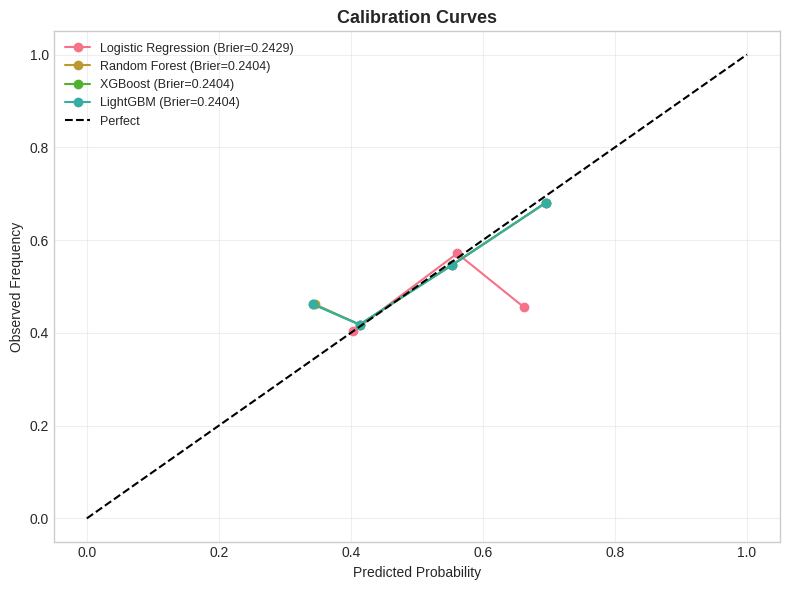

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Deployment Readiness

In [19]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print("=" * 60)
checks = {
    'AUC > 0.80': best_res['auc_mean'] > 0.80,
    'F1 > 0.75': best_res['f1_mean'] > 0.75,
    'Brier < 0.20': best_res['brier_mean'] < 0.20,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Random Forest
  ROC-AUC:              0.5981
  F1:                   0.4949
  Precision:            0.5849
  Recall:               0.4439
  Brier Score:          0.2404
  Training time:        1.2s
  Feature count:        2
  Dataset rows:         4,277
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.25

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [FAIL] AUC > 0.80
  [FAIL] F1 > 0.75
  [FAIL] Brier < 0.20
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Calibration assessed
--------------------------------------------------
  SOME CHECKS FAILED


In [20]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: Passenger manifest systems, booking platforms, service logs
   Ingestion: API -> Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (demographics, spending, cabin, services)
   Schedule: Pre-departure batch + real-time anomaly alerts

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time at boarding + batch pre-departure screening
   Output: Anomaly probability + contributing factors + recommended action

3. INTEGRATION POINTS
   ATSB: Anomaly pattern analytics for safety investigation
   CASA: Aviation passenger risk screening integration
   Transport operator: Boarding gate anomaly alerts
   Insurance: Passenger transport risk assessment

4. GOVERNANCE
   Privacy: Passenger data under Privacy Act 1988
   Explainability: Top contributing factors for each prediction
   Fairness: Monitor for demographic bias in anomaly detection
   Safety: All anomaly flags reviewed by human safety officer

5. MONITORING & RETRAINING
   Drift: PSI on passenger/spending features quarterly
   Performance: AUC on confirmed anomaly outcomes
   Retraining: Quarterly with new transport data

============================================================

NOTEBOOK #31 COMPLETE
Portfolio: kaggle.com/deanbatur | GitHub: github.com/Deanmeisong
============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: Passenger manifest systems, booking platforms, service logs
   Ingestion: API -> Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (demographics, spending, cabin, services)
   Schedule: Pre-departure batch + real-time anomaly alerts

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time at boarding + batch pre-departure screening
   Output: Anomaly probability + contributing factors + recommended action

3. INTEGRATION POINTS
   ATSB: Anomaly pattern analytics for safety investigation
   CASA: Aviation passenger risk screening integration
   Transport operator: Boarding gate anomaly alerts
   Insurance: Passenger transport risk assessment

4. GOVERNANCE
   Privacy: Passenger data under Privacy Act 1988
   Explainability: Top contributing factors for each prediction
   Fairness: Monitor for demographic bias in anomaly detection
   Safety: All anomaly flags reviewed 